# Sales Demand Forecasting - Enhanced Time Series Model

# Import necessary libraries 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Configure plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12

# Load data

In [10]:
df = pd.read_csv('Regional Sales Dataset.csv')

In [11]:
# Print basic info
df.info()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   OrderNumber                64104 non-null  object
 1   OrderDate                  64104 non-null  object
 2   Customer Name Index        64104 non-null  int64 
 3   Channel                    64104 non-null  object
 4   Currency Code              64104 non-null  object
 5   Warehouse Code             64104 non-null  object
 6   Delivery Region Index      64104 non-null  int64 
 7   Product Description Index  64104 non-null  int64 
 8   Order Quantity             64104 non-null  int64 
 9   Unit Price                 64104 non-null  object
 10  Line Total                 64104 non-null  object
 11  Total Unit Cost            64104 non-null  object
dtypes: int64(4), object(8)
memory usage: 5.9+ MB
    OrderNumber OrderDate  Customer Name Index      Channel Currency Co

# Initial EDA

In [12]:
print(df.columns)


Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost'],
      dtype='object')


Data shape: (64104, 12)
Missing values:
 OrderNumber                  0
OrderDate                    0
Customer Name Index          0
Channel                      0
Currency Code                0
Warehouse Code               0
Delivery Region Index        0
Product Description Index    0
Order Quantity               0
Unit Price                   0
Line Total                   0
Total Unit Cost              0
dtype: int64


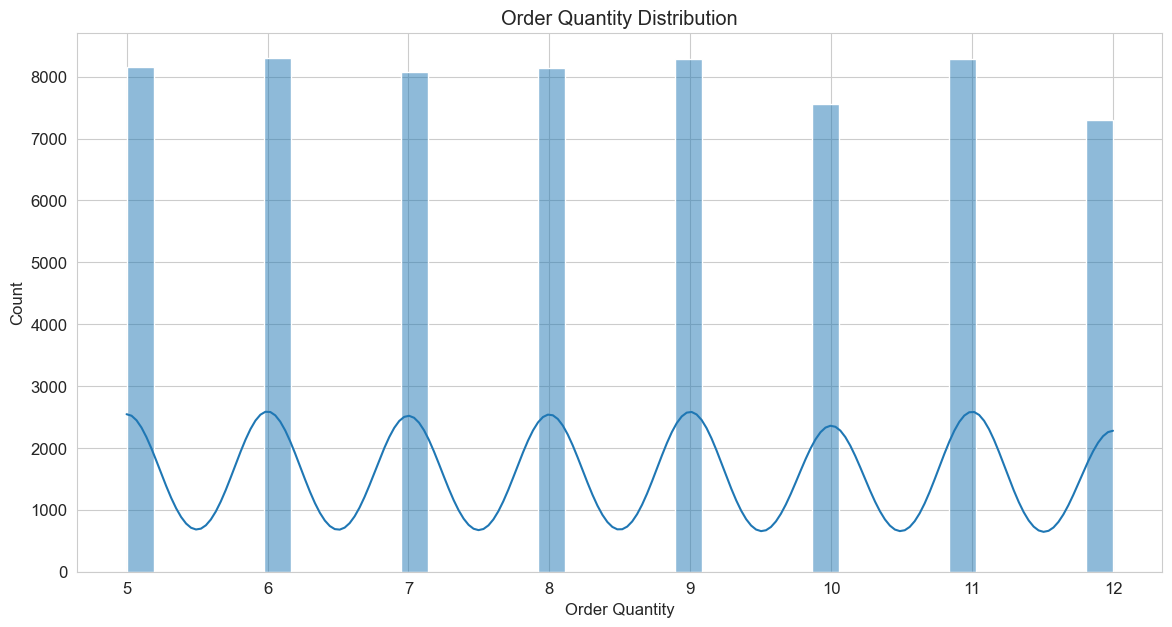

In [13]:
print('Data shape:', df.shape)
print('Missing values:\n', df.isnull().sum())
sns.histplot(df['Order Quantity'], kde=True)
plt.title('Order Quantity Distribution')
plt.show() 

* Time series plot

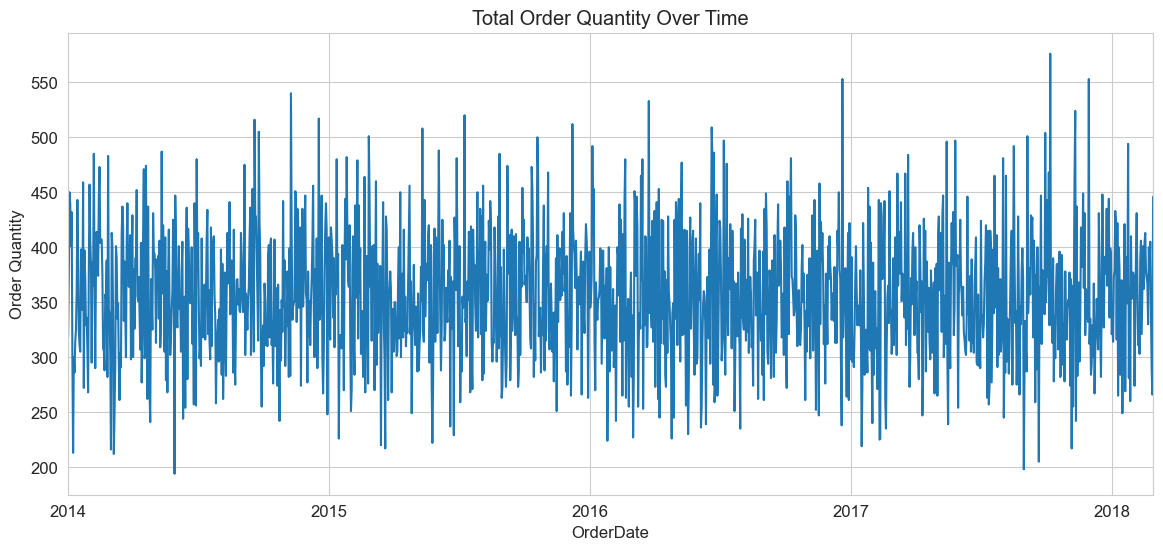

In [14]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])  # convert date column
plt.figure(figsize=(14, 6))
df.groupby('OrderDate')['Order Quantity'].sum().plot()
plt.title('Total Order Quantity Over Time')
plt.xlabel('OrderDate')
plt.ylabel('Order Quantity')
plt.show()


* Aggregate monthly total sales (Order Quantity)

In [15]:
monthly_sales = df.set_index('OrderDate').resample('M')['Order Quantity'].sum().reset_index()
monthly_sales.rename(columns={'OrderDate': 'ds', 'Order Quantity': 'y'}, inplace=True)

In [16]:
print(monthly_sales.head())

          ds      y
0 2014-01-31  10976
1 2014-02-28  10495
2 2014-03-31  10749
3 2014-04-30  10699
4 2014-05-31  11215


* Feature engineering: add time-based features and lags

In [17]:
monthly_sales['month'] = monthly_sales['ds'].dt.month
monthly_sales['quarter'] = monthly_sales['ds'].dt.quarter
monthly_sales['year'] = monthly_sales['ds'].dt.year

In [18]:
for lag in range(1, 4):
    monthly_sales[f'lag_{lag}'] = monthly_sales['y'].shift(lag)

In [19]:
monthly_sales['rolling_mean_3'] = monthly_sales['y'].rolling(window=3).mean()
monthly_sales['rolling_std_3'] = monthly_sales['y'].rolling(window=3).std()

In [20]:
monthly_sales.dropna(inplace=True)

In [21]:
print(monthly_sales.head())

          ds      y  month  quarter  year    lag_1    lag_2    lag_3  \
3 2014-04-30  10699      4        2  2014  10749.0  10495.0  10976.0   
4 2014-05-31  11215      5        2  2014  10699.0  10749.0  10495.0   
5 2014-06-30  10631      6        2  2014  11215.0  10699.0  10749.0   
6 2014-07-31  10774      7        3  2014  10631.0  11215.0  10699.0   
7 2014-08-31  10832      8        3  2014  10774.0  10631.0  11215.0   

   rolling_mean_3  rolling_std_3  
3    10647.666667     134.556060  
4    10887.666667     284.579222  
5    10848.333333     319.357689  
6    10873.333333     304.408169  
7    10745.666667     103.452082  


* Train-test split (last 12 months for testing)

In [22]:
test_size = 12
train = monthly_sales[:-test_size].copy()
test = monthly_sales[-test_size:].copy()

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (35, 10), Test shape: (12, 10)


* Prepare Prophet data with regressors

In [23]:
model_prophet = Prophet()
for col in ['month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']:
    model_prophet.add_regressor(col)

model_prophet.fit(train[['ds', 'y', 'month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']])

18:17:09 - cmdstanpy - INFO - Chain [1] start processing
18:17:32 - cmdstanpy - INFO - Chain [1] done processing


* Future dataframe and regressors for forecasting period

In [24]:
future = model_prophet.make_future_dataframe(periods=test_size, freq='M')
last_vals = monthly_sales.iloc[-test_size:]

In [25]:
for col in ['month', 'quarter', 'year', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_std_3']:
    future[col] = monthly_sales[col].values[-len(future):]

forecast = model_prophet.predict(future)

* Evaluate Prophet

In [26]:
prophet_pred = forecast.set_index('ds').loc[test['ds']]['yhat']
print("Prophet performance:")
def evaluate(y_true, y_pred):
    mape = mean_absolute_percentage_error(y_true, y_pred)*100
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    return mape, rmse, mae

evaluate(test['y'], prophet_pred)

Prophet performance:
MAPE: 0.24%
RMSE: 28.16
MAE: 25.83


(0.23948697872411795, 28.158117211560395, 25.833120355420153)

* ARIMA model

In [27]:
arima_train = train.set_index('ds')['y']
arima_test = test.set_index('ds')['y']

In [28]:
arima_model = auto_arima(arima_train, seasonal=True, m=12, stepwise=True,
                         suppress_warnings=True, trace=False)
print(arima_model.summary())

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                   35
Model:             SARIMAX(1, 0, 0)x(0, 1, 0, 12)   Log Likelihood                -168.764
Date:                            Tue, 14 Oct 2025   AIC                            341.529
Time:                                    18:22:36   BIC                            343.800
Sample:                                04-30-2014   HQIC                           342.100
                                     - 02-28-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3396      0.169     -2.011      0.044      -0.671      -0.009
sigma2      1.344e+05   4.71e+04   

In [29]:
arima_forecast = arima_model.predict(n_periods=test_size)

print("ARIMA performance:")
evaluate(arima_test, arima_forecast)

ARIMA performance:
MAPE: 1.99%
RMSE: 275.10
MAE: 212.44


(1.985036642017492, 275.09838184111743, 212.4383732246497)

* Plot forecasts vs actual

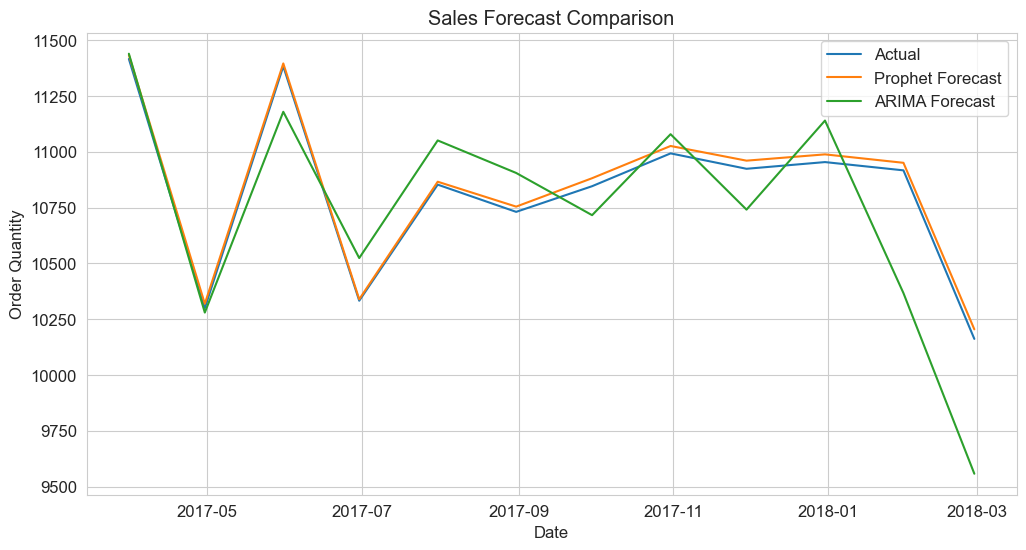

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual')
plt.plot(test['ds'], prophet_pred, label='Prophet Forecast')
plt.plot(test['ds'], arima_forecast, label='ARIMA Forecast')
plt.title('Sales Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Order Quantity')
plt.legend()
plt.grid(True)
plt.show()